<div style="text-align:center; padding:15px; color:white; margin:0; font-size:150%; font-family:'Times New Roman'; background-color:#008080; border-bottom:4px solid black; overflow:hidden">
    <b>RETAIL SUCCESS PREDICTIVE MODELING</b>
</div>

<div style="background-color:#1ABC9C; padding:15px; border-radius:8px">
<h2 style="color:white; text-align:center;">Project Overview</h2>
</div>

<p>
This project focuses on predicting product demand in a retail environment using machine learning techniques. 
The model analyzes factors such as historical sales, pricing, promotions, and economic conditions to estimate future demand.
This helps businesses make better decisions related to inventory management, pricing strategies, and promotional planning.
</p>

<div style="background-color:#AF7AC5; padding:15px; border-radius:8px">
<h2 style="color:white; text-align:center;">About the Dataset</h2>
</div>

<ul>
<li><b>product_id:</b> Unique identifier for each product</li>
<li><b>category_id:</b> Product category classification</li>
<li><b>store_id:</b> Store identifier</li>
<li><b>historical_sales:</b> Previous sales data</li>
<li><b>price:</b> Selling price of the product</li>
<li><b>promotion_flag:</b> Indicates if promotion is active (0/1)</li>
<li><b>holiday_flag:</b> Indicates if the day is a holiday</li>
<li><b>economic_index:</b> Represents market conditions</li>
<li><b>target_demand:</b> Demand to be predicted (target variable)</li>
</ul>

In [55]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,explained_variance_score
from math import sqrt
import warnings 
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
import numpy as np
from sklearn.model_selection import KFold,cross_val_score,train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.svm import SVC,SVR
from xgboost import XGBClassifier, XGBRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix,accuracy_score

In [56]:
import pandas as pd
df = pd.read_csv('/Users/mac/Documents/datasets/demand_forecasting_dataset (1).csv')
df.head()


,date,product_id,category_id,store_id,historical_sales,price,promotion_flag,holiday_flag,economic_index,target_demand
0,2022-01-02,1043,4,9,16,48.29,0,0,84.07,8
1,2022-01-02,1012,4,2,25,44.01,0,0,106.87,22
2,2022-01-03,1003,5,4,26,9.44,1,0,104.98,29
3,2022-01-03,1005,4,1,23,5.42,1,1,92.75,22
4,2022-01-04,1011,1,5,12,21.86,1,1,103.60,27


<div style="background-color:#F39C12; padding:15px; border-radius:8px;">
    <h2 style="color:white; text-align:center; font-family:'Georgia';">
        Data Preprocessing
    </h2>
</div>

<p style="font-family:'Georgia'; font-size:16px;">
The dataset is cleaned and transformed by converting date columns into meaningful features such as day, month, and year. 
Additional features like <b>sales-per-price</b> are created to improve model performance.
</p>

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4921 entries, 0 to 4920
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              4921 non-null   object 
 1   product_id        4921 non-null   int64  
 2   category_id       4921 non-null   int64  
 3   store_id          4921 non-null   int64  
 4   historical_sales  4921 non-null   int64  
 5   price             4921 non-null   float64
 6   promotion_flag    4921 non-null   int64  
 7   holiday_flag      4921 non-null   int64  
 8   economic_index    4921 non-null   float64
 9   target_demand     4921 non-null   int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 384.6+ KB


In [58]:
df.describe()

,product_id,category_id,store_id,historical_sales,price,promotion_flag,holiday_flag,economic_index,target_demand
count,4921.000000,4921.000000,4921.000000,4921.000000,4921.000000,4921.000000,4921.000000,4921.000000,4921.000000
mean,1024.328389,3.018492,5.453363,20.039626,27.209683,0.291607,0.152408,99.834089,22.421459
std,14.297004,1.422905,2.883354,4.398985,12.923657,0.454549,0.359452,9.870727,7.489883
min,1000.000000,1.000000,1.000000,5.000000,5.000000,0.000000,0.000000,69.320000,1.000000
25%,1012.000000,2.000000,3.000000,17.000000,15.950000,0.000000,0.000000,92.950000,17.000000
50%,1024.000000,3.000000,5.000000,20.000000,27.120000,0.000000,0.000000,99.570000,22.000000
75%,1037.000000,4.000000,8.000000,23.000000,38.370000,1.000000,0.000000,106.520000,27.000000
max,1049.000000,5.000000,10.000000,37.000000,49.990000,1.000000,1.000000,142.990000,53.000000


In [59]:
df.isnull().sum()

date                0
product_id          0
category_id         0
store_id            0
historical_sales    0
price               0
promotion_flag      0
holiday_flag        0
economic_index      0
target_demand       0
dtype: int64

In [60]:
df['date'] = pd.to_datetime(df['date'])

df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

In [61]:
df.drop('date', axis=1, inplace=True)

In [ ]:
df['date'] = pd.to_datetime(df['date'])

df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

In [ ]:
df.drop('date', axis=1, inplace=True)

In [17]:
df.dtypes

product_id            int64
category_id           int64
store_id              int64
historical_sales      int64
price               float64
promotion_flag        int64
holiday_flag          int64
economic_index      float64
target_demand         int64
day                   int32
month                 int32
year                  int32
dtype: object

In [18]:
df['sales_per_price'] = df['historical_sales'] / df['price']

In [20]:
X = df.drop(['target_demand', 'product_id', 'store_id'], axis=1)

<div style="background-color:#E74C3C; padding:15px; border-radius:8px">
<h2 style="color:white; text-align:center;">Exploratory Data Analysis</h2>
</div>


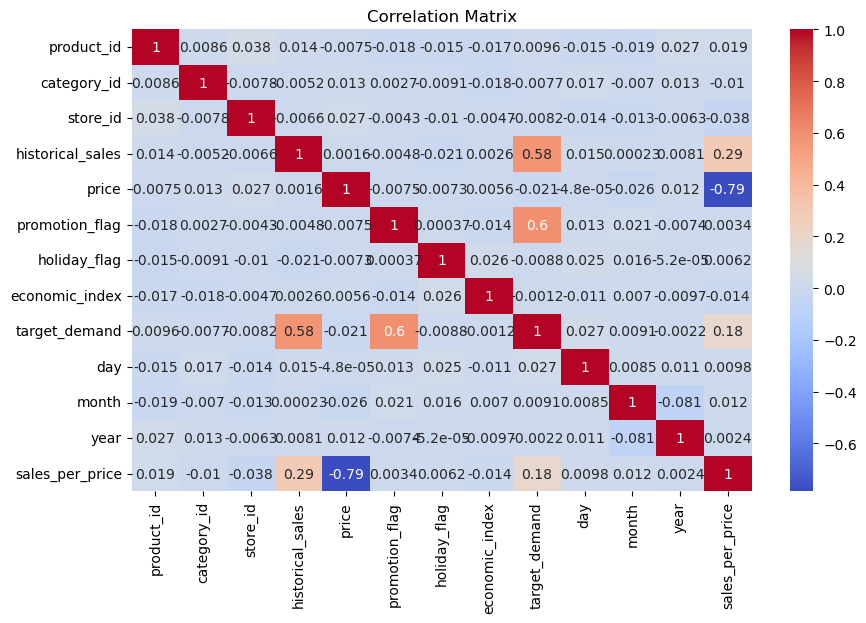

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

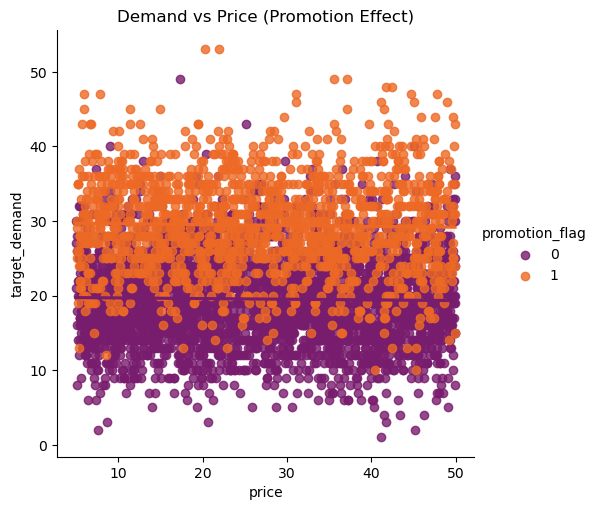

In [30]:
sns.lmplot(
    x="price",
    y="target_demand",
    hue="promotion_flag",
    data=df,
    palette="inferno"
)

plt.title("Demand vs Price (Promotion Effect)")
plt.show()

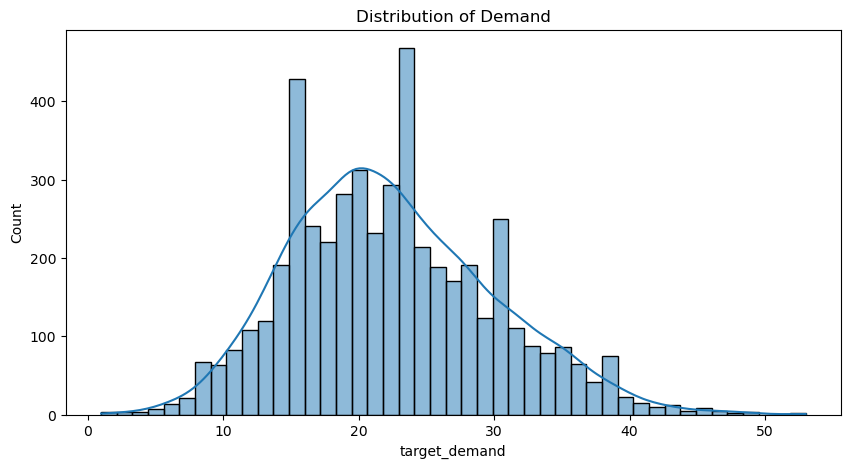

In [31]:
plt.figure(figsize=(10,5))
plt.title("Distribution of Demand")

sns.histplot(df["target_demand"], kde=True)

plt.show()

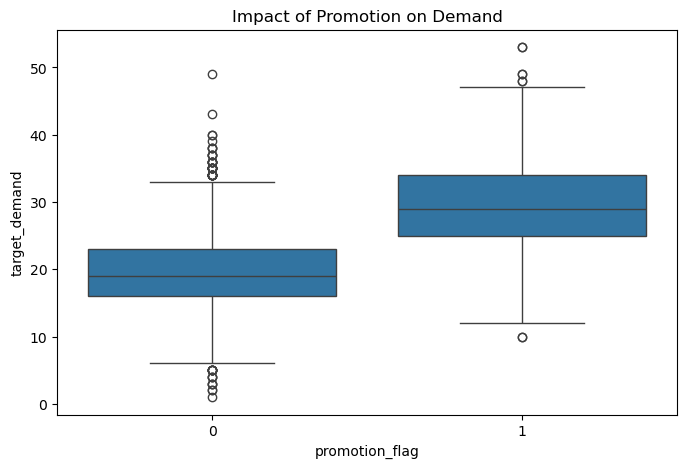

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x="promotion_flag", y="target_demand", data=df)

plt.title("Impact of Promotion on Demand")
plt.show()

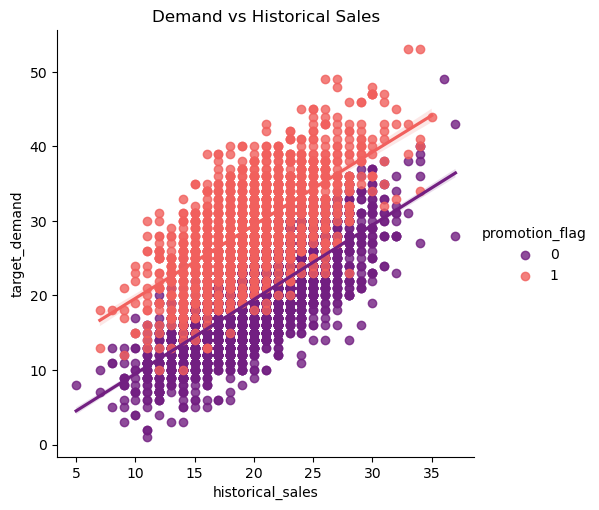

In [32]:
sns.lmplot(
    x="historical_sales",
    y="target_demand",
    hue="promotion_flag",
    data=df,
    palette="magma"
)

plt.title("Demand vs Historical Sales")
plt.show()

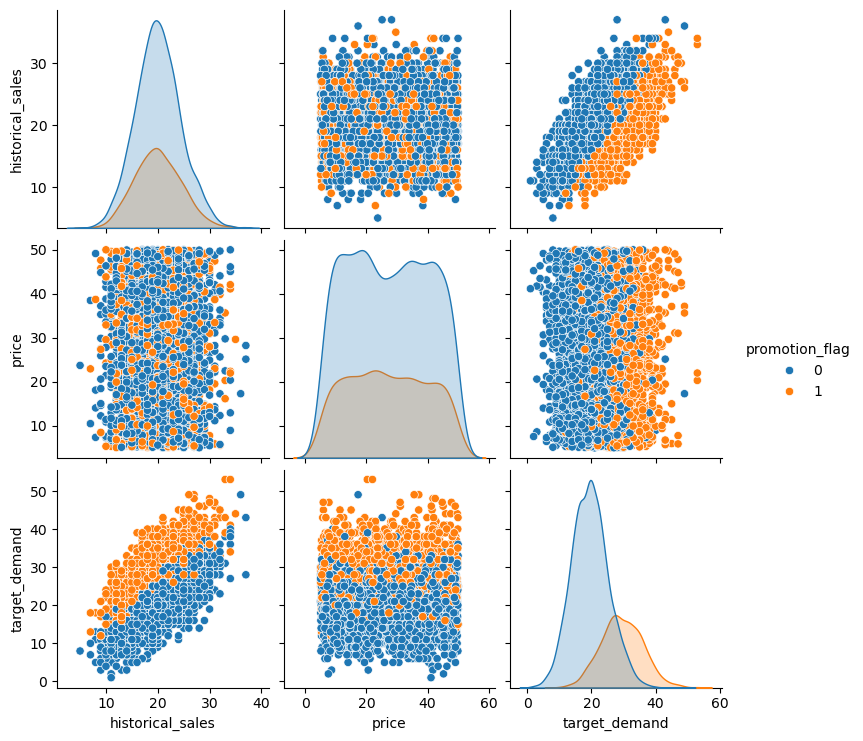

In [40]:
sns.pairplot(
    df[[
        'historical_sales',
        'price',
        'promotion_flag',
        'target_demandcorr = df.corr()['target_demand'].sort_values(ascending=False)
print(corr
    ]],
    hue='promotion_flag'
)

In [42]:
corr = df.corr()['target_demand'].sort_values(ascending=False)
print(corr)

target_demand       1.000000
promotion_flag      0.600960
historical_sales    0.579819
sales_per_price     0.180593
day                 0.026925
product_id          0.009650
month               0.009053
economic_index     -0.001153
year               -0.002229
category_id        -0.007693
store_id           -0.008172
holiday_flag       -0.008765
price              -0.021202
Name: target_demand, dtype: float64


<div style="background-color:#34495E; padding:15px; border-radius:8px">
<h2 style="color:white; text-align:center;">Model Building</h2>
</div>

<p>
A Random Forest Regressor is used to model demand prediction. 
This model is chosen due to its ability to capture non-linear relationships and handle complex feature interactions.
</p>

In [21]:
X = df.drop('target_demand', axis=1)
y = df['target_demand']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, n_estimators=200, random_state=42)

In [24]:
y_pred = rf.predict(X_test)

In [26]:
from sklearn.metrics import r2_score, mean_squared_error

<div style="background-color:#16A085; padding:15px; border-radius:8px">
<h2 style="color:white; text-align:center;">Model Evaluation</h2>
</div>

<p>
The model achieved an R² score of approximately 0.67, indicating good predictive performance. 
Mean Squared Error (MSE) is used to measure prediction error.
</p>

In [27]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.6734912281434837
MSE: 18.620459487246727


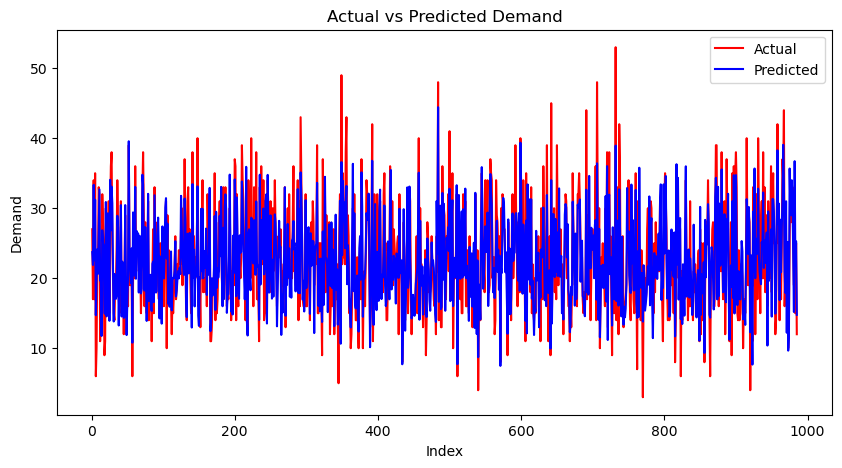

In [43]:
c = list(range(1, len(y_test)+1))

plt.figure(figsize=(10,5))
plt.plot(c, y_test.values, color='red', label='Actual')
plt.plot(c, y_pred, color='blue', label='Predicted')

plt.xlabel('Index')
plt.ylabel('Demand')
plt.title('Actual vs Predicted Demand')
plt.legend()

plt.show()

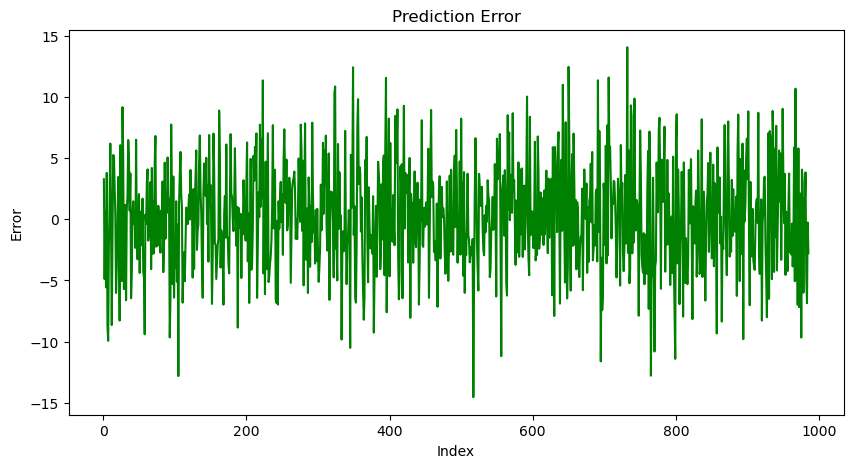

In [44]:
errors = y_test.values - y_pred

plt.figure(figsize=(10,5))
plt.plot(c, errors, color='green')

plt.xlabel('Index')
plt.ylabel('Error')
plt.title('Prediction Error')

plt.show()

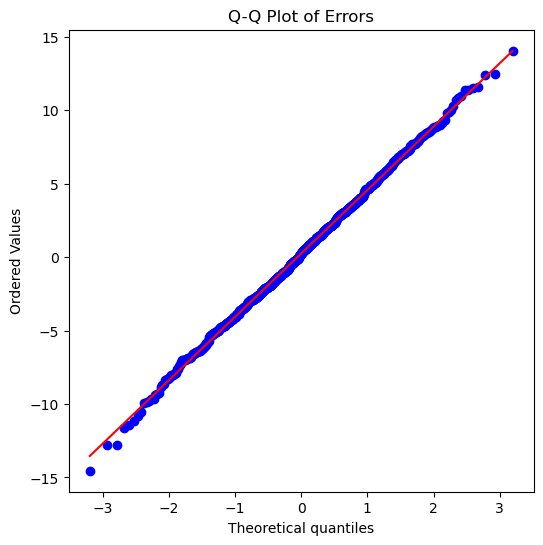

In [45]:
from scipy.stats import probplot

plt.figure(figsize=(6,6))
probplot(errors, dist='norm', plot=plt)

plt.title('Q-Q Plot of Errors')
plt.show()

<div style="background-color:#8E44AD; padding:15px; border-radius:8px">
<h2 style="color:white; text-align:center;">Testing with Sample Data</h2>
</div>

<p>
The trained model is tested using new input values.
</p>

In [47]:
input_data = pd.DataFrame({
    'product_id': [1043],
    'category_id': [4],
    'store_id': [9],
    'historical_sales': [20],
    'price': [30.0],
    'promotion_flag': [1],
    'holiday_flag': [0],
    'economic_index': [100.0],
    'day': [15],
    'month': [6],
    'year': [2022],
    'sales_per_price': [20/30.0]
})

In [48]:
predicted_demand = rf.predict(input_data)

print("Predicted Demand:", predicted_demand[0])

Predicted Demand: 30.25328906441976
